## 1. Notebook Configuration

The expected input file is:

`data/processed/hourly_n2000.parquet`

In [18]:
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler

pd.set_option('display.max_columns', 80)
pd.set_option('display.width', 140)
plt.rcParams['figure.figsize'] = (12, 5)

RANDOM_STATE = 42
DATA_PATH = '../data/processed/hourly_n2000.parquet'
OUTPUT_DIR = '../data/reports/rq1_forecasting'

if not os.path.exists(DATA_PATH):
    alt_path = 'data/processed/hourly_n2000.parquet'
    if os.path.exists(alt_path):
        DATA_PATH = alt_path

if not os.path.exists(OUTPUT_DIR):
    OUTPUT_DIR = 'data/reports/rq1_forecasting'

os.makedirs(OUTPUT_DIR, exist_ok=True)

print('DATA_PATH:', DATA_PATH)
print('OUTPUT_DIR:', OUTPUT_DIR)

DATA_PATH: ../data/processed/hourly_n2000.parquet
OUTPUT_DIR: data/reports/rq1_forecasting


## 2. Load Data

The model target is `avg_cpu_mean`, the hourly mean CPU utilization. The 24-hour forecast horizon is implemented by predicting CPU utilization 24 hours ahead.

In [19]:
df = pd.read_parquet(DATA_PATH)
df = df.sort_values(['vm_id', 'hour_index']).reset_index(drop=True)

print('Shape:', df.shape)
print('Unique VMs:', df['vm_id'].nunique())
print('Unique hours:', df['hour_index'].nunique())
df.head()

Shape: (1440000, 10)
Unique VMs: 2000
Unique hours: 720


,vm_id,hour_index,avg_cpu_mean,avg_cpu_min,avg_cpu_max,avg_cpu_std,readings_count,hour_of_day,day_index,day_of_cycle
0,0,0,1.467899,1.281514,1.953717,0.199937,12,0,0,0
1,0,1,1.555141,1.382086,2.036626,0.167614,12,1,0,0
2,0,2,1.683001,1.511600,2.219195,0.220013,12,2,0,0
3,0,3,1.752279,1.615813,2.279033,0.176076,12,3,0,0
4,0,4,1.926054,1.774914,2.230747,0.127170,12,4,0,0


In [20]:
required_cols = ['vm_id', 'hour_index', 'avg_cpu_mean', 'avg_cpu_max', 'avg_cpu_min', 'avg_cpu_std', 'hour_of_day', 'day_index', 'day_of_cycle']
missing_cols = [c for c in required_cols if c not in df.columns]

if missing_cols:
    raise ValueError(f'Missing required columns: {missing_cols}')

print(df[required_cols].isna().sum())
print('Duplicate VM-hour rows:', df.duplicated(['vm_id', 'hour_index']).sum())

vm_id           0
hour_index      0
avg_cpu_mean    0
avg_cpu_max     0
avg_cpu_min     0
avg_cpu_std     0
hour_of_day     0
day_index       0
day_of_cycle    0
dtype: int64
Duplicate VM-hour rows: 0


In [21]:
vm_summary = df.groupby('vm_id').agg(
    mean_cpu=('avg_cpu_mean', 'mean'),
    median_cpu=('avg_cpu_mean', 'median'),
    p95_cpu_mean=('avg_cpu_mean', lambda x: np.percentile(x, 95)),
    p95_cpu_max=('avg_cpu_max', lambda x: np.percentile(x, 95)),
    max_cpu=('avg_cpu_max', 'max'),
    std_cpu=('avg_cpu_mean', 'std'),
    mean_hourly_std=('avg_cpu_std', 'mean')
).reset_index()

## 3. Define Train, Validation, and Test Windows

Because this is time-series forecasting, random row-level splitting is avoided. The split below uses chronological windows:

- Training: hours 0 through 503      (21 days)
- Validation: hours 504 through 599  (4 days)
- Test: hours 600 through 719        (5 days)

A 24-hour ahead target is created, so rows near the end of each VM series will not have a target and are removed after feature engineering.

In [22]:
TRAIN_END = 503
VAL_END = 599
TEST_END = 719
FORECAST_HORIZON = 24

print('Train hours:', 0, 'to', TRAIN_END)
print('Validation hours:', TRAIN_END + 1, 'to', VAL_END)
print('Test hours:', VAL_END + 1, 'to', TEST_END)
print('Forecast horizon:', FORECAST_HORIZON, 'hours')

Train hours: 0 to 503
Validation hours: 504 to 599
Test hours: 600 to 719
Forecast horizon: 24 hours


## 4. Feature Engineering for Forecasting

Features are designed to capture:

- **Short-term memory:** lag 1, lag 2, lag 3
- **Daily seasonality:** lag 24 and rolling 24-hour statistics
- **Weekly-cycle behavior:** lag 168 and rolling 168-hour statistics
- **Recent volatility:** rolling standard deviation
- **Cyclical time position:** sine/cosine encoding for hour of day and day of cycle

The target is CPU utilization 24 hours ahead.

In [23]:
def add_forecasting_features(input_df, target_col='avg_cpu_mean', horizon=24):
    data = input_df.sort_values(['vm_id', 'hour_index']).copy()
    group = data.groupby('vm_id', group_keys=False)

    # Target shifted backward so current features predict future utilization
    data['target_t_plus_24'] = group[target_col].shift(-horizon)

    # Lag features
    for lag in [1, 2, 3, 6, 12, 24, 48, 168]:
        data[f'lag_{lag}'] = group[target_col].shift(lag)

    # Rolling features shifted by 1 to avoid leakage from current target period
    for window in [3, 6, 12, 24, 168]:
        data[f'roll_mean_{window}'] = group[target_col].shift(1).rolling(window=window, min_periods=window).mean().reset_index(level=0, drop=True)
        data[f'roll_std_{window}'] = group[target_col].shift(1).rolling(window=window, min_periods=window).std().reset_index(level=0, drop=True)
        data[f'roll_min_{window}'] = group[target_col].shift(1).rolling(window=window, min_periods=window).min().reset_index(level=0, drop=True)
        data[f'roll_max_{window}'] = group[target_col].shift(1).rolling(window=window, min_periods=window).max().reset_index(level=0, drop=True)

    # Cyclical encoding
    data['hour_sin'] = np.sin(2 * np.pi * data['hour_of_day'] / 24)
    data['hour_cos'] = np.cos(2 * np.pi * data['hour_of_day'] / 24)
    data['day_cycle_sin'] = np.sin(2 * np.pi * data['day_of_cycle'] / 7)
    data['day_cycle_cos'] = np.cos(2 * np.pi * data['day_of_cycle'] / 7)

    # Additional utilization context
    data['hourly_range'] = data['avg_cpu_max'] - data['avg_cpu_min']
    data['peak_to_mean'] = data['avg_cpu_max'] / (data['avg_cpu_mean'] + 1e-6)

    return data

features_df = add_forecasting_features(df, horizon=FORECAST_HORIZON)
print('Shape after feature engineering:', features_df.shape)
features_df.head()

Shape after feature engineering: (1440000, 45)


,vm_id,hour_index,avg_cpu_mean,avg_cpu_min,avg_cpu_max,avg_cpu_std,readings_count,hour_of_day,day_index,day_of_cycle,target_t_plus_24,lag_1,lag_2,lag_3,lag_6,lag_12,lag_24,lag_48,lag_168,roll_mean_3,roll_std_3,roll_min_3,roll_max_3,roll_mean_6,roll_std_6,roll_min_6,roll_max_6,roll_mean_12,roll_std_12,roll_min_12,roll_max_12,roll_mean_24,roll_std_24,roll_min_24,roll_max_24,roll_mean_168,roll_std_168,roll_min_168,roll_max_168,hour_sin,hour_cos,day_cycle_sin,day_cycle_cos,hourly_range,peak_to_mean
0,0,0,1.467899,1.281514,1.953717,0.199937,12,0,0,0,1.694079,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,1.000000,0.0,1.0,0.672203,1.330961
1,0,1,1.555141,1.382086,2.036626,0.167614,12,1,0,0,1.911016,1.467899,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.258819,0.965926,0.0,1.0,0.654540,1.309608
2,0,2,1.683001,1.511600,2.219195,0.220013,12,2,0,0,2.053228,1.555141,1.467899,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.500000,0.866025,0.0,1.0,0.707595,1.318593
3,0,3,1.752279,1.615813,2.279033,0.176076,12,3,0,0,2.235990,1.683001,1.555141,1.467899,NaN,NaN,NaN,NaN,NaN,1.568680,0.108188,1.467899,1.683001,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.707107,0.707107,0.0,1.0,0.663220,1.300610
4,0,4,1.926054,1.774914,2.230747,0.127170,12,4,0,0,2.391764,1.752279,1.683001,1.555141,NaN,NaN,NaN,NaN,NaN,1.663474,0.100009,1.555141,1.752279,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.866025,0.500000,0.0,1.0,0.455833,1.158195


In [24]:
feature_cols = [
    c for c in features_df.columns
    if c.startswith('lag_') or c.startswith('roll_') or c in [
        'avg_cpu_mean', 'avg_cpu_max', 'avg_cpu_min', 'avg_cpu_std',
        'readings_count', 'hour_sin', 'hour_cos', 'day_cycle_sin', 'day_cycle_cos',
        'hourly_range', 'peak_to_mean'
    ]
]

# Keep only available columns
feature_cols = [c for c in feature_cols if c in features_df.columns]
model_df = features_df.dropna(subset=feature_cols + ['target_t_plus_24']).copy()

print('Number of features:', len(feature_cols))
print(feature_cols)
print('Modeling rows:', model_df.shape)

Number of features: 39
['avg_cpu_mean', 'avg_cpu_min', 'avg_cpu_max', 'avg_cpu_std', 'readings_count', 'lag_1', 'lag_2', 'lag_3', 'lag_6', 'lag_12', 'lag_24', 'lag_48', 'lag_168', 'roll_mean_3', 'roll_std_3', 'roll_min_3', 'roll_max_3', 'roll_mean_6', 'roll_std_6', 'roll_min_6', 'roll_max_6', 'roll_mean_12', 'roll_std_12', 'roll_min_12', 'roll_max_12', 'roll_mean_24', 'roll_std_24', 'roll_min_24', 'roll_max_24', 'roll_mean_168', 'roll_std_168', 'roll_min_168', 'roll_max_168', 'hour_sin', 'hour_cos', 'day_cycle_sin', 'day_cycle_cos', 'hourly_range', 'peak_to_mean']
Modeling rows: (1056000, 45)


## 5. Chronological Modeling Splits

Rows are assigned to train/validation/test sets based on the time when the prediction is made, not the target time.

In [25]:
train_df = model_df[model_df['hour_index'] <= TRAIN_END].copy()
val_df = model_df[(model_df['hour_index'] > TRAIN_END) & (model_df['hour_index'] <= VAL_END)].copy()
test_df = model_df[(model_df['hour_index'] > VAL_END) & (model_df['hour_index'] <= TEST_END - FORECAST_HORIZON)].copy()

print('Train:', train_df.shape)
print('Validation:', val_df.shape)
print('Test:', test_df.shape)

X_train, y_train = train_df[feature_cols], train_df['target_t_plus_24']
X_val, y_val = val_df[feature_cols], val_df['target_t_plus_24']
X_test, y_test = test_df[feature_cols], test_df['target_t_plus_24']

Train: (672000, 45)
Validation: (192000, 45)
Test: (192000, 45)


## 6. Evaluation Metrics

The main metrics are:

- MAE: Mean Absolute Error
- RMSE: Root Mean Squared Error
- MAPE: Mean Absolute Percentage Error, with small actual values stabilized to avoid division by zero
- sMAPE: Symmetric Mean Absolute Percentage Error

MAPE can be unstable when actual CPU utilization is close to zero, so MAE and RMSE should also be reported.

In [26]:
def regression_metrics(y_true, y_pred, model_name, split_name):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    eps = 1e-3

    mae = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / np.maximum(np.abs(y_true), eps))) * 100
    smape = np.mean(2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred) + eps)) * 100

    return {
        'model': model_name,
        'split': split_name,
        'MAE': mae,
        'RMSE': rmse,
        'MAPE': mape,
        'sMAPE': smape
    }

results = []

## 7. Baseline Forecasting Models

Baseline models establish the performance floor that more complex models must beat.

- **Naive baseline:** predicts the current CPU value for 24 hours ahead.
- **Seasonal naive baseline:** predicts the value from the same hour on the previous day.
- **Moving average baseline:** predicts the recent 24-hour rolling average.

In [27]:
def evaluate_baseline(data, pred_col, model_name, split_name):
    valid = data.dropna(subset=[pred_col, 'target_t_plus_24'])
    metrics = regression_metrics(valid['target_t_plus_24'], valid[pred_col], model_name, split_name)
    return metrics

for split_name, split_data in [('Validation', val_df), ('Test', test_df)]:
    results.append(evaluate_baseline(split_data, 'avg_cpu_mean', 'Naive last-value', split_name))
    results.append(evaluate_baseline(split_data, 'lag_24', 'Seasonal naive lag-24', split_name))
    results.append(evaluate_baseline(split_data, 'roll_mean_24', 'Moving average 24-hour', split_name))

pd.DataFrame(results)

,model,split,MAE,RMSE,MAPE,sMAPE
0,Naive last-value,Validation,1.116286,24.643768,22.318810,12.497072
1,Seasonal naive lag-24,Validation,1.304976,30.064270,22.643883,14.027643
2,Moving average 24-hour,Validation,1.282409,24.138958,27.352407,15.003904
3,Naive last-value,Test,1.055494,21.241821,23.313911,12.126560
4,Seasonal naive lag-24,Test,1.373274,30.183830,31.865772,14.875385
5,Moving average 24-hour,Test,1.233296,17.642156,29.150811,16.259907


## 8. XGBoost or Gradient Boosting Model

XGBoost is used if installed. If XGBoost is not available, the notebook falls back to `HistGradientBoostingRegressor` from scikit-learn so the workflow remains executable.

In [28]:
try:
    from xgboost import XGBRegressor
    xgb_model = XGBRegressor(
        n_estimators=300,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective='reg:squarederror',
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
    tree_model_name = 'XGBoost'
except Exception as e:
    print('XGBoost not available. Falling back to HistGradientBoostingRegressor.')
    from sklearn.ensemble import HistGradientBoostingRegressor
    xgb_model = HistGradientBoostingRegressor(
        max_iter=300,
        learning_rate=0.05,
        max_leaf_nodes=31,
        random_state=RANDOM_STATE
    )
    tree_model_name = 'HistGradientBoosting fallback'

xgb_model.fit(X_train, y_train)

val_pred_xgb = np.clip(xgb_model.predict(X_val), 0, 100)
test_pred_xgb = np.clip(xgb_model.predict(X_test), 0, 100)

results.append(regression_metrics(y_val, val_pred_xgb, tree_model_name, 'Validation'))
results.append(regression_metrics(y_test, test_pred_xgb, tree_model_name, 'Test'))

pd.DataFrame(results).sort_values(['split', 'RMSE'])

,model,split,MAE,RMSE,MAPE,sMAPE
7,XGBoost,Test,1.037534,13.150521,34.605919,17.030853
5,Moving average 24-hour,Test,1.233296,17.642156,29.150811,16.259907
3,Naive last-value,Test,1.055494,21.241821,23.313911,12.126560
4,Seasonal naive lag-24,Test,1.373274,30.183830,31.865772,14.875385
6,XGBoost,Validation,1.136048,19.589809,37.509644,17.260315
2,Moving average 24-hour,Validation,1.282409,24.138958,27.352407,15.003904
0,Naive last-value,Validation,1.116286,24.643768,22.318810,12.497072
1,Seasonal naive lag-24,Validation,1.304976,30.064270,22.643883,14.027643


,feature,importance
0,avg_cpu_mean,0.441357
25,roll_mean_24,0.219530
21,roll_mean_12,0.059072
15,roll_min_3,0.050528
13,roll_mean_3,0.038890
11,lag_48,0.036372
5,lag_1,0.029903
10,lag_24,0.021429
29,roll_mean_168,0.017144
16,roll_max_3,0.011429


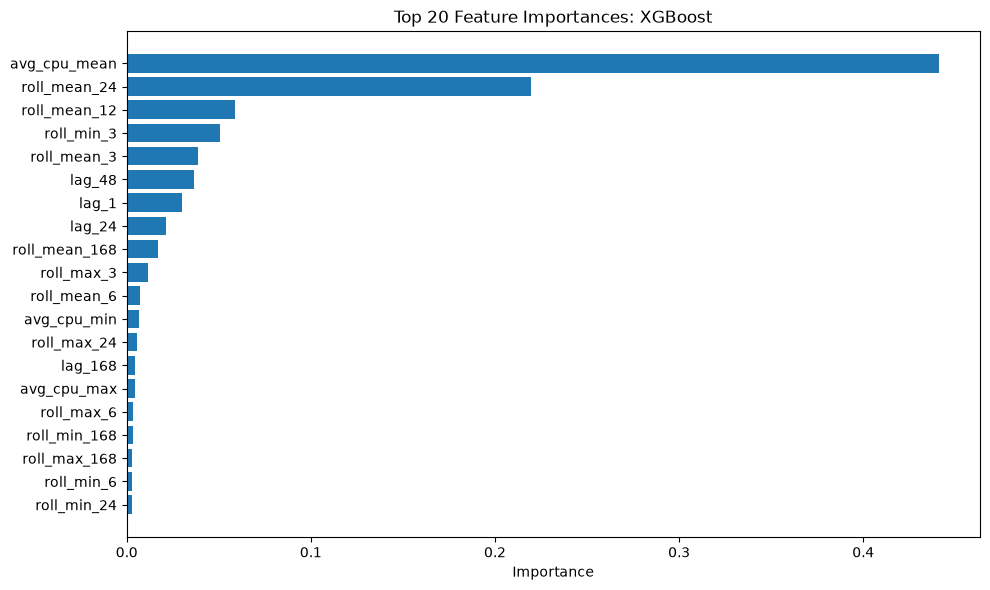

In [29]:
# Feature importance for tree-based model if available
if hasattr(xgb_model, 'feature_importances_'):
    importance = pd.DataFrame({
        'feature': feature_cols,
        'importance': xgb_model.feature_importances_
    }).sort_values('importance', ascending=False)

    display(importance.head(20))

    plt.figure(figsize=(10, 6))
    top_imp = importance.head(20).sort_values('importance')
    plt.barh(top_imp['feature'], top_imp['importance'])
    plt.title(f'Top 20 Feature Importances: {tree_model_name}')
    plt.xlabel('Importance')
    plt.tight_layout()
    plt.show()
else:
    print('Feature importance is not available for this model.')

## 9. Workload Archetype Grouping for Model Comparison

To evaluate whether model performance differs across steady and bursty VMs, this section assigns simple CPU-based workload groups. These are not final RQ3 clusters, but they provide an interim forecasting comparison by utilization behavior.

In [30]:
# Build VM-level summary for interim workload groups.
# This is needed for grouping VMs into low-utilization, high-utilization, bursty, and moderate/steady categories.
vm_summary = df.groupby('vm_id').agg(
    mean_cpu=('avg_cpu_mean', 'mean'),
    std_cpu=('avg_cpu_mean', 'std'),
    p95_cpu=('avg_cpu_mean', lambda x: np.percentile(x, 95))
).reset_index()

vm_summary['burstiness_index'] = vm_summary['p95_cpu'] / (vm_summary['mean_cpu'] + 1e-6)

# Simple interim workload groups based on VM-level summaries.
# These are not final RQ3 clusters, but they support RQ1 model comparison by behavior type.
# Simple interim workload groups based on VM-level summaries
q_low = vm_summary['mean_cpu'].quantile(0.33)
q_high = vm_summary['mean_cpu'].quantile(0.66)
burst_q = vm_summary['burstiness_index'].quantile(0.75)

conditions = [
    vm_summary['burstiness_index'] >= burst_q,
    vm_summary['mean_cpu'] <= q_low,
    vm_summary['mean_cpu'] >= q_high
]
choices = ['Bursty', 'Low utilization', 'High utilization']
vm_summary['interim_workload_group'] = np.select(conditions, choices, default='Moderate/steady')

vm_groups = vm_summary[['vm_id', 'interim_workload_group']]
test_with_preds = test_df[['vm_id', 'hour_index', 'target_t_plus_24']].copy()
test_with_preds['seasonal_naive_pred'] = test_df['lag_24'].values
test_with_preds['tree_model_pred'] = test_pred_xgb
test_with_preds = test_with_preds.merge(vm_groups, on='vm_id', how='left')

vm_summary['interim_workload_group'].value_counts()

interim_workload_group
Moderate/steady     551
Bursty              500
Low utilization     496
High utilization    453
Name: count, dtype: int64

In [31]:
group_results = []
for group_name, group_data in test_with_preds.groupby('interim_workload_group'):
    group_results.append(regression_metrics(
        group_data['target_t_plus_24'],
        group_data['seasonal_naive_pred'],
        'Seasonal naive lag-24',
        f'Test - {group_name}'
    ))
    group_results.append(regression_metrics(
        group_data['target_t_plus_24'],
        group_data['tree_model_pred'],
        tree_model_name,
        f'Test - {group_name}'
    ))

group_results_df = pd.DataFrame(group_results).sort_values(['split', 'RMSE'])
group_results_df

,model,split,MAE,RMSE,MAPE,sMAPE
1,XGBoost,Test - Bursty,2.399121,35.632111,62.131466,32.525894
0,Seasonal naive lag-24,Test - Bursty,3.155650,73.829857,86.583115,29.910347
3,XGBoost,Test - High utilization,1.140215,10.517807,9.058599,8.162059
2,Seasonal naive lag-24,Test - High utilization,1.550111,28.646736,13.431101,10.106890
5,XGBoost,Test - Low utilization,0.172680,0.942110,56.990135,17.732737
4,Seasonal naive lag-24,Test - Low utilization,0.179300,1.814338,13.033592,9.782344
7,XGBoost,Test - Moderate/steady,0.496080,5.904053,10.481768,9.629599
6,Seasonal naive lag-24,Test - Moderate/steady,0.685282,17.379034,14.321293,9.737082


## 10. ARIMA on Bursty VMs

In [32]:
bursty_vm_ids = vm_summary.loc[vm_summary['interim_workload_group'] == 'Bursty','vm_id'].tolist()
print(f'Number of bursty VMs: {len(bursty_vm_ids)}')

Number of bursty VMs: 500


In [33]:
from statsmodels.tsa.arima.model import ARIMA
import numpy as np


def arima_forecast_for_vm(vm_id, order=(2, 1, 2)):

    temp = (
        df[df['vm_id'] == vm_id]
        .sort_values('hour_index')
        .copy()
    )

    series = temp.set_index('hour_index')['avg_cpu_mean']

    train_series = series[
        series.index <= TRAIN_END
    ]

    test_series = series[
        (series.index > VAL_END) &
        (series.index <= TEST_END)
    ]

    if len(train_series) < 50 or len(test_series) == 0:
        return None

    try:

        model = ARIMA(
            train_series,
            order=order,
            enforce_stationarity=False,
            enforce_invertibility=False
        )

        fitted = model.fit(
            method_kwargs={"maxiter": 200}
        )

        steps = TEST_END - TRAIN_END

        forecast = fitted.forecast(
            steps=steps
        )

        forecast.index = range(
            TRAIN_END + 1,
            TEST_END + 1
        )

        eval_index = (
            test_series.index
            .intersection(forecast.index)
        )

        y_true_arima = test_series.loc[eval_index]

        y_pred_arima = np.clip(
            forecast.loc[eval_index],
            0,
            100
        )

        metric = regression_metrics(
            y_true_arima,
            y_pred_arima,
            f'ARIMA{order} vm_id={vm_id}',
            'Bursty VM Test'
        )

        return (
            metric,
            y_true_arima,
            y_pred_arima
        )

    except Exception as e:

        print(
            f'ARIMA failed for vm_id={vm_id}: {e}'
        )

        return None

In [34]:
arima_results = []
all_y_true = []
all_y_pred = []

for vm in bursty_vm_ids:
    out = arima_forecast_for_vm(vm)
    if out is not None:

        metric, y_true, y_pred = out

        arima_results.append(metric)

        all_y_true.extend(y_true.values)
        all_y_pred.extend(y_pred.values)

print(f'Successful ARIMA runs: {len(arima_results)}')

Successful ARIMA runs: 500


In [35]:
arima_results_df = pd.DataFrame(arima_results)
arima_results_df.head()

,model,split,MAE,RMSE,MAPE,sMAPE
0,"ARIMA(2, 1, 2) vm_id=0",Bursty VM Test,0.670702,0.592727,50.997756,73.358802
1,"ARIMA(2, 1, 2) vm_id=7",Bursty VM Test,0.414406,0.311045,30.552618,31.463157
2,"ARIMA(2, 1, 2) vm_id=12",Bursty VM Test,8.218541,68.852705,78.444913,129.254231
3,"ARIMA(2, 1, 2) vm_id=14",Bursty VM Test,1.904647,26.564743,64.100590,54.854618
4,"ARIMA(2, 1, 2) vm_id=15",Bursty VM Test,0.239454,0.144627,6.984057,7.504719


In [36]:
arima_overall = regression_metrics(
    np.array(all_y_true),
    np.array(all_y_pred),
    'ARIMA',
    'Bursty VM Test'
)

arima_overall_df = pd.DataFrame(
    [arima_overall]
)

arima_overall_df

,model,split,MAE,RMSE,MAPE,sMAPE
0,ARIMA,Bursty VM Test,4.761294,117.37437,77.138376,49.494164


## 11.Running Prophet on Bursty VMs

In [37]:
!pip install plotly

In [38]:
from prophet import Prophet
import pandas as pd
import numpy as np


def prophet_forecast_for_vm(vm_id):

    temp = (
        df[df['vm_id'] == vm_id]
        .sort_values('hour_index')
        .copy()
    )

    # Create hourly timestamps
    temp['ds'] = pd.Timestamp('2024-01-01') + pd.to_timedelta(
        temp['hour_index'],
        unit='h'
    )

    temp['y'] = temp['avg_cpu_mean']

    train_df_prophet = temp[
        temp['hour_index'] <= TRAIN_END
    ][['ds', 'y']]

    test_df_prophet = temp[
        (temp['hour_index'] > VAL_END) &
        (temp['hour_index'] <= TEST_END)
    ][['ds', 'y', 'hour_index']]

    if len(train_df_prophet) < 50 or len(test_df_prophet) == 0:
        return None

    try:

        model = Prophet(
            daily_seasonality=True,
            weekly_seasonality=True,
            yearly_seasonality=False
        )

        model.fit(train_df_prophet)

        forecast_end = temp.loc[
            temp['hour_index'] <= TEST_END,
            'ds'
        ].max()

        future = model.make_future_dataframe(
            periods=TEST_END - TRAIN_END,
            freq='h'
        )

        forecast = model.predict(future)

        forecast = forecast[['ds', 'yhat']]

        merged = test_df_prophet.merge(
            forecast,
            on='ds',
            how='left'
        )

        y_true_prophet = merged['y']
        y_pred_prophet = np.clip(
            merged['yhat'],
            0,
            100
        )

        metric = regression_metrics(
            y_true_prophet,
            y_pred_prophet,
            f'Prophet vm_id={vm_id}',
            'Bursty VM Test'
        )

        return (
            metric,
            y_true_prophet,
            y_pred_prophet
        )

    except Exception as e:

        print(
            f'Prophet failed for vm_id={vm_id}: {e}'
        )

        return None

In [39]:
bursty_vm_ids = vm_summary.loc[
    vm_summary['interim_workload_group'] == 'Bursty',
    'vm_id'
].tolist()

In [40]:
prophet_results = []

all_y_true = []
all_y_pred = []

for vm in bursty_vm_ids:

    out = prophet_forecast_for_vm(vm)

    if out is not None:

        metric, y_true, y_pred = out

        prophet_results.append(metric)

        all_y_true.extend(y_true.values)
        all_y_pred.extend(y_pred.values)

print(
    f'Successful Prophet runs: {len(prophet_results)}'
)

18:57:20 - cmdstanpy - INFO - Chain [1] start processing
18:57:20 - cmdstanpy - INFO - Chain [1] done processing
18:57:21 - cmdstanpy - INFO - Chain [1] start processing
18:57:21 - cmdstanpy - INFO - Chain [1] done processing
18:57:22 - cmdstanpy - INFO - Chain [1] start processing
18:57:22 - cmdstanpy - INFO - Chain [1] done processing
18:57:22 - cmdstanpy - INFO - Chain [1] start processing
18:57:22 - cmdstanpy - INFO - Chain [1] done processing
18:57:23 - cmdstanpy - INFO - Chain [1] start processing
18:57:23 - cmdstanpy - INFO - Chain [1] done processing
18:57:24 - cmdstanpy - INFO - Chain [1] start processing
18:57:24 - cmdstanpy - INFO - Chain [1] done processing
18:57:24 - cmdstanpy - INFO - Chain [1] start processing
18:57:24 - cmdstanpy - INFO - Chain [1] done processing
18:57:25 - cmdstanpy - INFO - Chain [1] start processing
18:57:25 - cmdstanpy - INFO - Chain [1] done processing
18:57:26 - cmdstanpy - INFO - Chain [1] start processing
18:57:26 - cmdstanpy - INFO - Chain [1]

Successful Prophet runs: 500


In [41]:
prophet_results_df = pd.DataFrame(
    prophet_results
)

prophet_results_df.head()

,model,split,MAE,RMSE,MAPE,sMAPE
0,Prophet vm_id=0,Bursty VM Test,0.353047,0.206748,42.804530,30.579503
1,Prophet vm_id=7,Bursty VM Test,1.210114,1.770410,100.000000,199.809706
2,Prophet vm_id=12,Bursty VM Test,9.750444,96.834975,93.572093,177.995234
3,Prophet vm_id=14,Bursty VM Test,1.918954,26.247992,64.909867,59.175486
4,Prophet vm_id=15,Bursty VM Test,2.480932,7.571752,78.249660,125.099148


In [42]:
prophet_overall = regression_metrics(
    np.array(all_y_true),
    np.array(all_y_pred),
    'Prophet',
    'Bursty VM Test'
)

prophet_overall_df = pd.DataFrame(
    [prophet_overall]
)

prophet_overall_df

,model,split,MAE,RMSE,MAPE,sMAPE
0,Prophet,Bursty VM Test,6.772577,198.482197,152.599799,79.937693


## 12. LSTM Model

In [43]:
feature_scaler = StandardScaler()
target_scaler = StandardScaler()

X_train_scaled = feature_scaler.fit_transform(X_train)
X_val_scaled = feature_scaler.transform(X_val)
X_test_scaled = feature_scaler.transform(X_test)

y_train_scaled = target_scaler.fit_transform(
    y_train.values.reshape(-1, 1)
)

y_val_scaled = target_scaler.transform(
    y_val.values.reshape(-1, 1)
)


In [44]:
X_train_lstm = X_train_scaled.reshape(
    X_train_scaled.shape[0],
    1,
    X_train_scaled.shape[1]
)

X_val_lstm = X_val_scaled.reshape(
    X_val_scaled.shape[0],
    1,
    X_val_scaled.shape[1]
)

X_test_lstm = X_test_scaled.reshape(
    X_test_scaled.shape[0],
    1,
    X_test_scaled.shape[1]
)

In [45]:
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    LSTM,
    Dense,
    Dropout
)
from tensorflow.keras.callbacks import EarlyStopping

In [46]:
lstm_model = Sequential([

    LSTM(
        64,
        input_shape=(
            X_train_lstm.shape[1],
            X_train_lstm.shape[2]
        )
    ),

    Dropout(0.2),

    Dense(
        32,
        activation='relu'
    ),

    Dense(1)

])

In [47]:
lstm_model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

In [48]:
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [49]:
history = lstm_model.fit(
    X_train_lstm,
    y_train_scaled,
    validation_data=(
        X_val_lstm,
        y_val_scaled
    ),
    epochs=30,
    batch_size=512,
    callbacks=[early_stopping],
    verbose=1
)


Epoch 1/30
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 21s 12ms/step - loss: 0.1098 - mae: 0.1109 - val_loss: 0.1378 - val_mae: 0.1001
Epoch 2/30
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 16s 12ms/step - loss: 0.0954 - mae: 0.0991 - val_loss: 0.1377 - val_mae: 0.0991
Epoch 3/30
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 15s 11ms/step - loss: 0.0939 - mae: 0.0975 - val_loss: 0.1391 - val_mae: 0.0967
Epoch 4/30
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 15s 11ms/step - loss: 0.0921 - mae: 0.0965 - val_loss: 0.1346 - val_mae: 0.0967
Epoch 5/30
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - loss: 0.0913 - mae: 0.0960 - val_loss: 0.1366 - val_mae: 0.1009
Epoch 6/30
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 21s 12ms/step - loss: 0.0902 - mae: 0.0954 - val_loss: 0.1341 - val_mae: 0.1092
Epoch 7/30
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 16s 12ms/step - loss: 0.0891 - mae: 0.0945 - val_loss: 0.1331 - val_mae: 0.1107
Epoch 8/30
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 15s 11ms/step - loss: 0.0885 - mae: 0.0939 - val_loss: 0.1348 - val_mae: 0.1099
Epoch 9/30
1313/1313 ━━━

In [50]:
lstm_test_pred_scaled = lstm_model.predict(
    X_test_lstm,
    verbose=0
)

lstm_test_pred = target_scaler.inverse_transform(
    lstm_test_pred_scaled
).flatten()

lstm_test_pred = np.clip(
    lstm_test_pred,
    0,
    100
)

In [51]:
bursty_vm_ids = vm_summary.loc[
    vm_summary['interim_workload_group'] == 'Bursty',
    'vm_id'
].tolist()

In [52]:
bursty_test_mask = (
    test_df['vm_id']
    .isin(bursty_vm_ids)
)

In [53]:
lstm_bursty_metrics = regression_metrics(
    test_df.loc[
        bursty_test_mask,
        'target_t_plus_24'
    ],
    lstm_test_pred[bursty_test_mask],
    'LSTM',
    'Test - Bursty'
)

In [54]:
lstm_bursty_results_df = pd.DataFrame(
    [lstm_bursty_metrics]
)

lstm_bursty_results_df

,model,split,MAE,RMSE,MAPE,sMAPE
0,LSTM,Test - Bursty,2.603347,36.296635,122.469864,48.374561


## 13.Overall Result comparison

In [55]:
bursty_results_df = (
    group_results_df[
        group_results_df['split'] == 'Test - Bursty'
    ]
    .drop(columns=['split'])
    .reset_index(drop=True)
)
additional_results = pd.DataFrame([
    arima_overall,
    prophet_overall,
    lstm_bursty_metrics
]).drop(columns=['split'], errors='ignore')

bursty_results_df = pd.concat(
    [bursty_results_df, additional_results],
    ignore_index=True
)

bursty_results_df

,model,MAE,RMSE,MAPE,sMAPE
0,XGBoost,2.399121,35.632111,62.131466,32.525894
1,Seasonal naive lag-24,3.155650,73.829857,86.583115,29.910347
2,ARIMA,4.761294,117.374370,77.138376,49.494164
3,Prophet,6.772577,198.482197,152.599799,79.937693
4,LSTM,2.603347,36.296635,122.469864,48.374561


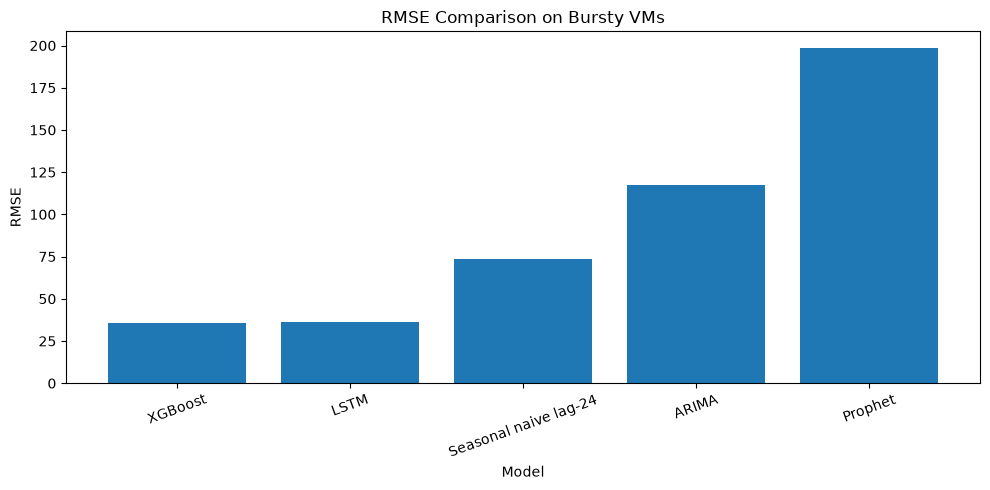

In [56]:
import matplotlib.pyplot as plt

# Sort by RMSE for cleaner visualization
rmse_df = bursty_results_df.sort_values('RMSE')

plt.figure(figsize=(10, 5))
plt.bar(rmse_df['model'], rmse_df['RMSE'])
plt.title('RMSE Comparison on Bursty VMs')
plt.xlabel('Model')
plt.ylabel('RMSE')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

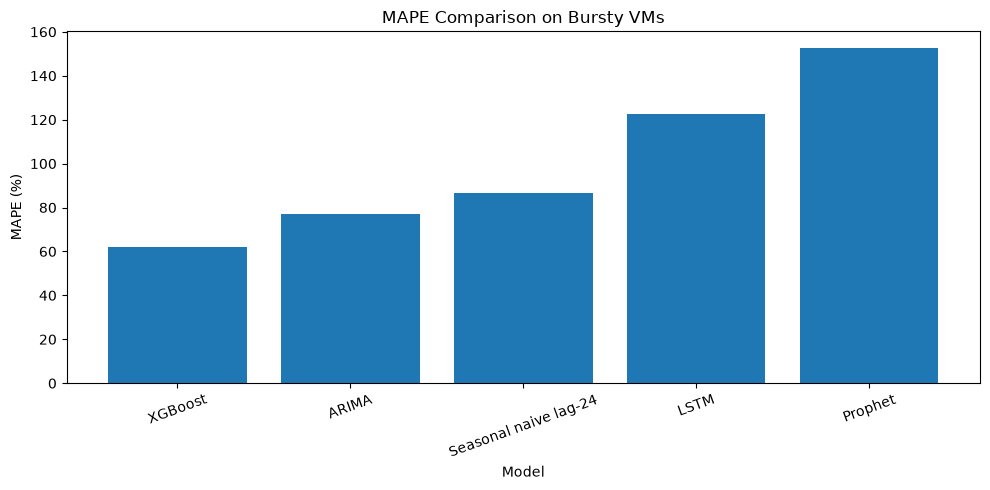

In [57]:
# Sort by MAPE for cleaner visualization
mape_df = bursty_results_df.sort_values('MAPE')

plt.figure(figsize=(10, 5))
plt.bar(mape_df['model'], mape_df['MAPE'])
plt.title('MAPE Comparison on Bursty VMs')
plt.xlabel('Model')
plt.ylabel('MAPE (%)')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


## 14. Hypothesis Test: Improvement Over Seasonal Naive Baseline

H1 states that LSTM and XGBoost reduce RMSE by at least 15 percent compared with models like ARIMA on bursty VMs. This section calculates the percentage improvement for the tree-based model. If LSTM results are available, add the LSTM improvement comparison as well.

In [58]:
arima_rmse = bursty_results_df.loc[
    bursty_results_df['model'] == 'ARIMA',
    'RMSE'
].iloc[0]

xgb_rmse = bursty_results_df.loc[
    bursty_results_df['model'] == 'XGBoost',
    'RMSE'
].iloc[0]

improvement_pct = (
    (arima_rmse - xgb_rmse)
    / arima_rmse
) * 100

print(f'ARIMA RMSE: {arima_rmse:.2f}%')
print(f'XGBoost RMSE: {xgb_rmse:.2f}%')
print(f'Improvement over ARIMA: {improvement_pct:.2f}%')

ARIMA RMSE: 117.37%
XGBoost RMSE: 35.63%
Improvement over ARIMA: 69.64%


## 15. Visualize Forecasts for Example VMs

This section plots actual versus predicted CPU utilization for example low-utilization, high-utilization, bursty, and moderate/steady VMs in the test period.


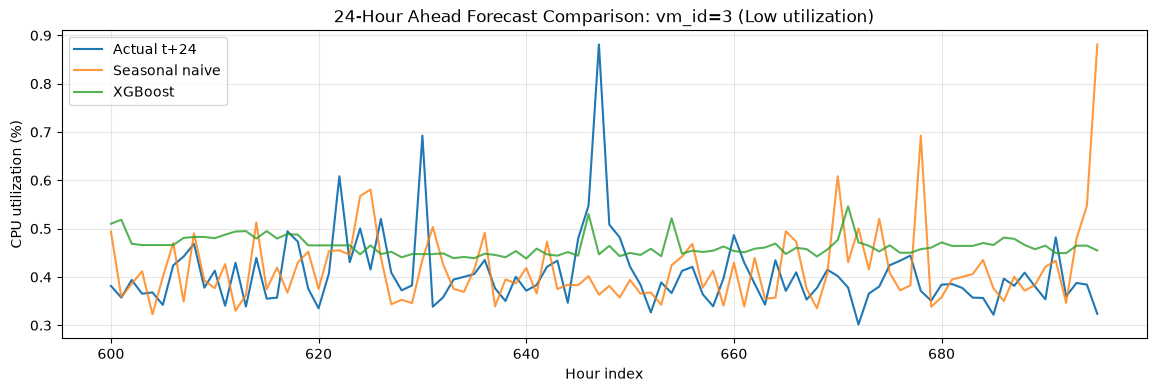

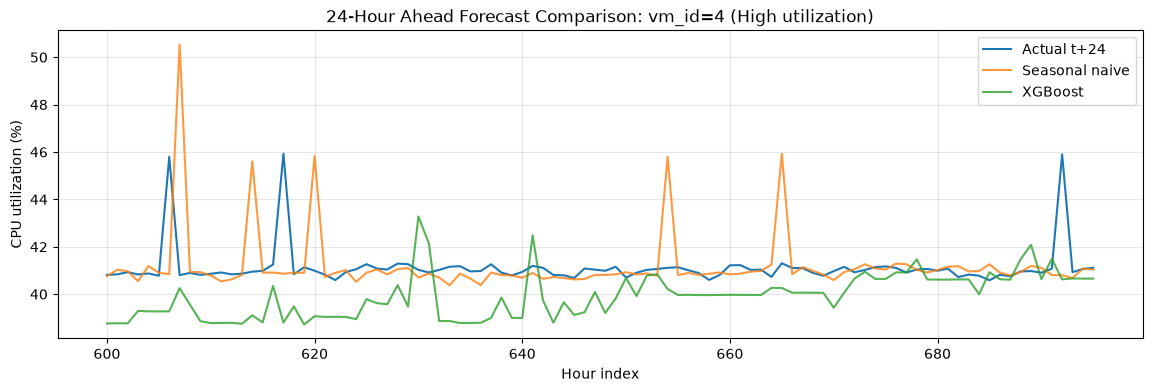

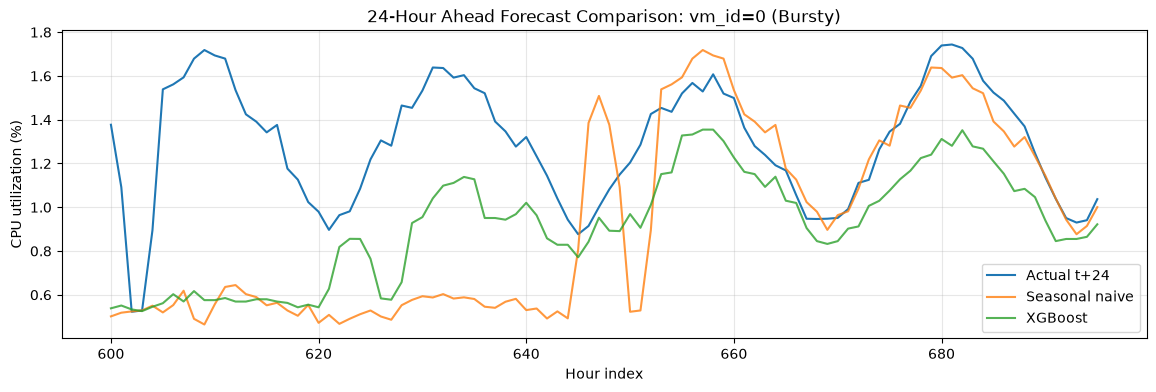

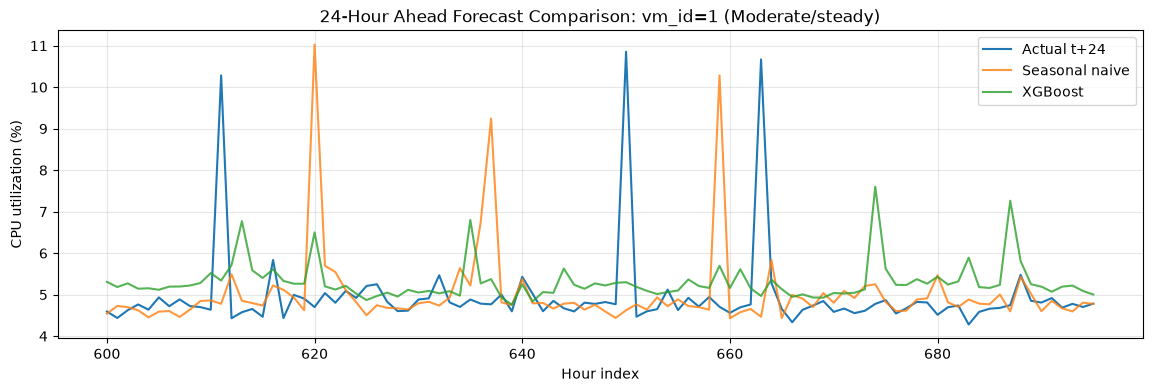

In [59]:
# Select example VMs from interim workload groups for visualization
example_vms = []
for group_name in ['Low utilization', 'High utilization', 'Bursty', 'Moderate/steady']:
    candidate = vm_summary[vm_summary['interim_workload_group'] == group_name]
    if not candidate.empty:
        example_vms.append(int(candidate.iloc[0]['vm_id']))

for vm in example_vms:
    temp = test_with_preds[test_with_preds['vm_id'] == vm].sort_values('hour_index')
    if temp.empty:
        continue

    group_name = temp['interim_workload_group'].iloc[0]
    plt.figure(figsize=(14, 4))
    plt.plot(temp['hour_index'], temp['target_t_plus_24'], label='Actual t+24')
    plt.plot(temp['hour_index'], temp['seasonal_naive_pred'], label='Seasonal naive', alpha=0.8)
    plt.plot(temp['hour_index'], temp['tree_model_pred'], label=tree_model_name, alpha=0.8)
    plt.title(f'24-Hour Ahead Forecast Comparison: vm_id={vm} ({group_name})')
    plt.xlabel('Hour index')
    plt.ylabel('CPU utilization (%)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()


## 16. Save RQ1 Results

This section saves model metrics and prediction outputs for use in the interim or final report.

In [60]:
results_df = pd.DataFrame(results)

results_path = os.path.join(
    OUTPUT_DIR,
    'rq1_model_metrics.csv'
)

bursty_results_path = os.path.join(
    OUTPUT_DIR,
    'rq1_bursty_model_metrics.csv'
)

predictions_path = os.path.join(
    OUTPUT_DIR,
    'rq1_test_predictions.csv'
)

# Save outputs
results_df.to_csv(
    results_path,
    index=False
)

bursty_results_df.to_csv(
    bursty_results_path,
    index=False
)

test_with_preds.to_csv(
    predictions_path,
    index=False
)

print('Saved results:')
print(results_path)
print(bursty_results_path)
print(predictions_path)

bursty_results_df

Saved results:
data/reports/rq1_forecasting\rq1_model_metrics.csv
data/reports/rq1_forecasting\rq1_bursty_model_metrics.csv
data/reports/rq1_forecasting\rq1_test_predictions.csv


,model,MAE,RMSE,MAPE,sMAPE
0,XGBoost,2.399121,35.632111,62.131466,32.525894
1,Seasonal naive lag-24,3.155650,73.829857,86.583115,29.910347
2,ARIMA,4.761294,117.374370,77.138376,49.494164
3,Prophet,6.772577,198.482197,152.599799,79.937693
4,LSTM,2.603347,36.296635,122.469864,48.374561


## 17. Save XGBoost model for Streamlite dashboard

In [61]:
import joblib

MODEL_DIR = "saved_models"
os.makedirs(MODEL_DIR, exist_ok=True)

# Save model
joblib.dump(
    xgb_model,
    os.path.join(MODEL_DIR, "rq1_xgboost_model.pkl")
)

# Save feature names
joblib.dump(
    feature_cols,
    os.path.join(MODEL_DIR, "rq1_feature_columns.pkl")
)

print("Model saved successfully.")
print(f"Model: {os.path.join(MODEL_DIR, 'rq1_xgboost_model.pkl')}")
print(f"Features: {os.path.join(MODEL_DIR, 'rq1_feature_columns.pkl')}")

Model saved successfully.
Model: saved_models\rq1_xgboost_model.pkl
Features: saved_models\rq1_feature_columns.pkl
